In [1]:
from pathlib import Path
import json

DATA_ROOT = Path("synthetic_runs1T_FK_2c")  # 250-patient dataset

samples = sorted([p for p in DATA_ROOT.glob("synthetic1T_run*") if p.is_dir()])
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("Num samples:", len(samples))
print("First sample:", samples[0] if samples else None)

params = json.loads((samples[0] / "parameters.json").read_text())
print("Parameter keys:", list(params.keys()))
print("Example params:", {k: params[k] for k in ("Dw", "rho")})


DATA_ROOT exists: True
Num samples: 250
First sample: synthetic_runs1T_FK_2c\synthetic1T_run100
Parameter keys: ['th_necro_n', 'th_enhancing_p', 'th_edema_p', 'Dw', 'rho', 'lambda_np', 'sigma_np', 'D_s', 'lambda_s', 'gm_path', 'wm_path', 'NxT1_pct', 'NyT1_pct', 'NzT1_pct', 'resolution_factor', 'RatioDw_Dg', 'th_matter', 'th_necro', 'dx_mm', 'dy_mm', 'dz_mm', 'init_scale', 'time_series_solution_Nt', 'Nt_multiplier', 'output_dir']
Example params: {'Dw': 1.459503618461283, 'rho': 0.7087988562347525}


In [2]:
TARGET_KEYS = ("Dw", "rho") 


In [3]:
import random
random.seed(42)
random.shuffle(samples)

n = len(samples)
train = samples[:int(0.7*n)]
val   = samples[int(0.7*n):int(0.85*n)]
test  = samples[int(0.85*n):]

print("Split sizes:", len(train), len(val), len(test))


Split sizes: 175 37 38


In [4]:
import numpy as np
import json

def get_y(sample_dir):
    p = json.loads((sample_dir/"parameters.json").read_text())
    vals = []
    for k in TARGET_KEYS:
        v = float(p[k])
        if k == "Dw":
            v = np.log(v)
        vals.append(v)
    return np.array(vals, dtype=np.float32)

Y_train = np.stack([get_y(s) for s in train], axis=0)
Y_MEAN = Y_train.mean(axis=0)
Y_STD  = Y_train.std(axis=0) + 1e-6

print("Y_MEAN:", Y_MEAN)
print("Y_STD :", Y_STD)


Y_MEAN: [0.34416467 0.3797969 ]
Y_STD : [0.9162873  0.23868617]


In [5]:
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import json

def read_nii(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)  # (D,H,W)
    return arr

def bbox_from_mask(mask, margin=12):
    idx = np.argwhere(mask)
    if idx.size == 0:
        return None
    z0,y0,x0 = idx.min(axis=0)
    z1,y1,x1 = idx.max(axis=0) + 1
    z0 = max(z0 - margin, 0); y0 = max(y0 - margin, 0); x0 = max(x0 - margin, 0)
    z1 = min(z1 + margin, mask.shape[0]); y1 = min(y1 + margin, mask.shape[1]); x1 = min(x1 + margin, mask.shape[2])
    return (z0,z1,y0,y1,x0,x1)

def crop(arr, bb):
    z0,z1,y0,y1,x0,x1 = bb
    return arr[z0:z1, y0:y1, x0:x1]

def resize_3d(arr, out_shape=(96,96,96)):
    t = torch.from_numpy(arr)[None,None,...]
    t = F.interpolate(t, size=out_shape, mode="trilinear", align_corners=False)
    return t[0,0].numpy()

def normalize_channel(arr):
    m = arr.mean()
    s = arr.std()
    return (arr - m) / (s + 1e-6)

class TumorParamDatasetCached(Dataset):
    """
    Loads + preprocesses every sample once at init, then serves from RAM.
    Great for small datasets (like 50 patients) and avoids DataLoader worker crashes.
    """
    def __init__(self, sample_dirs, input_mode="physics", out_shape=(96,96,96), target_keys=("Dw","rho","D_s"), verbose=True):
        self.sample_dirs = sample_dirs
        self.input_mode = input_mode
        self.out_shape = out_shape
        self.target_keys = target_keys

        self.cache = []
        if verbose:
            print(f"Caching {len(sample_dirs)} samples... (one-time cost)")

        for i, sd in enumerate(self.sample_dirs):
            x, y = self._load_one(sd)
            self.cache.append((x, y))
            if verbose and (i+1) % 10 == 0:
                print(f"  cached {i+1}/{len(sample_dirs)}")

        if verbose:
            print("Caching done.")

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        return self.cache[idx]

    def _load_one(self, sd):
        # ---- Targets (normalized using training stats) ----
        params = json.loads((sd/"parameters.json").read_text())
        vals = []
        for k in self.target_keys:
            v = float(params[k])
            if k == "Dw":
                v = np.log(v)  # <-- log transform
            vals.append(v)

        y_raw = np.array(vals, dtype=np.float32)
        y_norm = (y_raw - Y_MEAN) / Y_STD
        y = torch.tensor(y_norm, dtype=torch.float32)

        # ---- Inputs ----
        segm = read_nii(sd/"segm.nii.gz")
        bb = bbox_from_mask(segm > 0, margin=12)

        if self.input_mode == "physics":
            chans = [
                read_nii(sd/"P.nii.gz"),
                read_nii(sd/"N.nii.gz"),
                read_nii(sd/"S.nii.gz"),
                (segm > 0).astype(np.float32),
            ]
        else:  # imaging
            chans = [
                read_nii(sd/"FET.nii.gz"),
                read_nii(sd/"wm_data.nii.gz"),
                read_nii(sd/"gm_data.nii.gz"),
                (segm > 0).astype(np.float32),
            ]

        processed = []
        for c in chans:
            if bb is not None:
                c = crop(c, bb)
            c = resize_3d(c, self.out_shape)

            # normalize non-binary channels
            if np.unique(c).size > 2:
                c = normalize_channel(c)

            processed.append(c)

        x = torch.from_numpy(np.stack(processed, axis=0)).float()  # (C,D,H,W)
        return x, y


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler


class CNN3DRegressor(nn.Module):
    def __init__(self, in_channels, out_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels, 32, 3, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True),
            nn.MaxPool3d(2),

            nn.Conv3d(128, 256, 3, padding=1),
            nn.BatchNorm3d(256), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.head(self.features(x))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device=="cuda" else "")

MODE = "physics"
OUT_SHAPE = (96,96,96)

# ---- Cache datasets (one-time preprocessing) ----
train_ds = TumorParamDatasetCached(train, input_mode=MODE, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True)
val_ds   = TumorParamDatasetCached(val,   input_mode=MODE, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True)

# ---- DataLoader settings ----
# With caching, workers aren't needed. Keep 0 for maximum stability.
NUM_WORKERS = 0

# Increase batch size now that IO/preprocessing is gone.
# Try 8 first; if you OOM, drop to 4.
BATCH_SIZE = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

model = CNN3DRegressor(in_channels=4, out_dim=len(TARGET_KEYS)).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = GradScaler()
loss_fn = nn.MSELoss()
def mae(pred, y):
    return (pred - y).abs().mean()

EPOCHS = 300 

# ---- Best validation checkpoint ----
best_val_mse = float("inf")
best_state = None
best_epoch = -1

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss = tr_mae = 0.0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with autocast():
            pred = model(x)
            loss = loss_fn(pred, y)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        tr_loss += loss.item()
        tr_mae  += mae(pred.detach(), y).item()

    model.eval()
    va_loss = va_mae = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with autocast():
                pred = model(x)
                loss = loss_fn(pred, y)
            va_loss += loss.item()
            va_mae  += mae(pred, y).item()

    val_mse = va_loss / len(val_loader)

    # Save best model weights
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:03d} | train MSE {tr_loss/len(train_loader):.4f} MAE {tr_mae/len(train_loader):.4f} "
      f"| val MSE {val_mse:.4f} MAE {va_mae/len(val_loader):.4f} "
      f"| best val {best_val_mse:.4f} @ {best_epoch:03d}")

# Restore best model before testing
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\n✅ Loaded best model from epoch {best_epoch} with val MSE {best_val_mse:.6f}")


Device: cuda NVIDIA GeForce RTX 5080
Caching 175 samples... (one-time cost)
  cached 10/175
  cached 20/175
  cached 30/175
  cached 40/175
  cached 50/175
  cached 60/175
  cached 70/175
  cached 80/175
  cached 90/175
  cached 100/175
  cached 110/175
  cached 120/175
  cached 130/175
  cached 140/175
  cached 150/175
  cached 160/175
  cached 170/175
Caching done.
Caching 37 samples... (one-time cost)
  cached 10/37
  cached 20/37
  cached 30/37
Caching done.


C:\Users\Grant\AppData\Local\Temp\ipykernel_52052\3928417223.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\Grant\AppData\Local\Temp\ipykernel_52052\3928417223.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
C:\Users\Grant\AppData\Local\Temp\ipykernel_52052\3928417223.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001 | train MSE 0.6678 MAE 0.6609 | val MSE 0.8003 MAE 0.7523 | best val 0.8003 @ 001
Epoch 002 | train MSE 0.4547 MAE 0.5500 | val MSE 0.3513 MAE 0.4580 | best val 0.3513 @ 002
Epoch 003 | train MSE 0.3682 MAE 0.4783 | val MSE 0.5255 MAE 0.6172 | best val 0.3513 @ 002
Epoch 004 | train MSE 0.4122 MAE 0.5024 | val MSE 0.7789 MAE 0.7372 | best val 0.3513 @ 002
Epoch 005 | train MSE 0.4094 MAE 0.5103 | val MSE 0.2627 MAE 0.4141 | best val 0.2627 @ 005
Epoch 006 | train MSE 0.3324 MAE 0.4434 | val MSE 0.2228 MAE 0.3474 | best val 0.2228 @ 006
Epoch 007 | train MSE 0.2671 MAE 0.4059 | val MSE 0.3565 MAE 0.4821 | best val 0.2228 @ 006
Epoch 008 | train MSE 0.2321 MAE 0.3842 | val MSE 0.2530 MAE 0.3812 | best val 0.2228 @ 006
Epoch 009 | train MSE 0.2803 MAE 0.4191 | val MSE 0.2044 MAE 0.3355 | best val 0.2044 @ 009
Epoch 010 | train MSE 0.2415 MAE 0.3932 | val MSE 0.2535 MAE 0.3836 | best val 0.2044 @ 009
Epoch 011 | train MSE 0.2451 MAE 0.3882 | val MSE 0.2195 MAE 0.3511 | best val 0

Caching 38 samples... (one-time cost)
  cached 10/38
  cached 20/38
  cached 30/38
Caching done.
Dw: MAE=0.441873 RMSE=0.575593
rho: MAE=0.085001 RMSE=0.109192


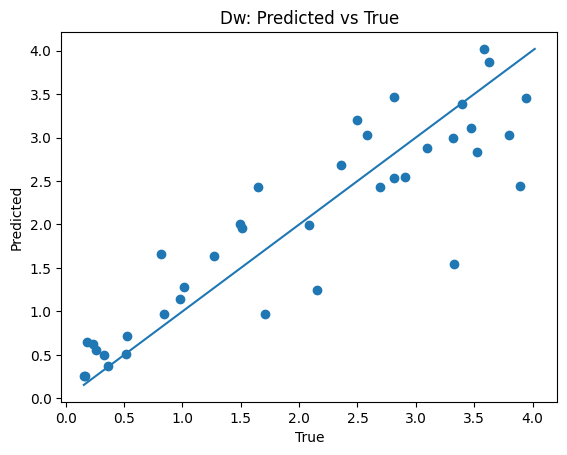

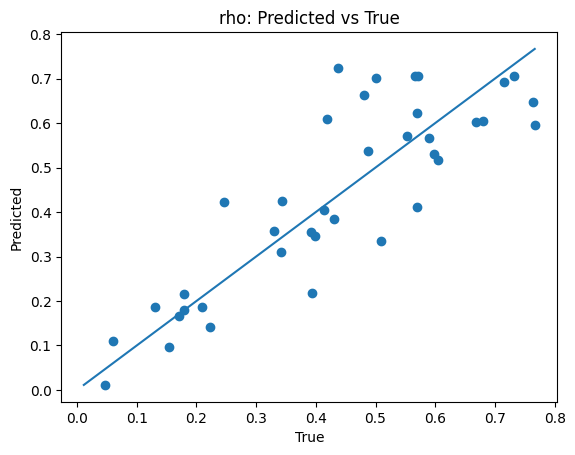

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch

test_ds = TumorParamDatasetCached(test, input_mode=MODE, out_shape=OUT_SHAPE, target_keys=TARGET_KEYS, verbose=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

model.eval()
preds_norm, trues_norm = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        pred = model(x).cpu().numpy()[0]
        preds_norm.append(pred)
        trues_norm.append(y.numpy()[0])

preds_norm = np.array(preds_norm)
trues_norm = np.array(trues_norm)

# Denormalize back to original parameter scale
preds = preds_norm * Y_STD + Y_MEAN
trues = trues_norm * Y_STD + Y_MEAN

# If Dw was trained in log-space, convert it back
for i, k in enumerate(TARGET_KEYS):
    if k == "Dw":
        preds[:, i] = np.exp(preds[:, i])
        trues[:, i] = np.exp(trues[:, i])

for i,k in enumerate(TARGET_KEYS):
    mae_i = np.abs(preds[:,i] - trues[:,i]).mean()
    rmse_i = np.sqrt(((preds[:,i] - trues[:,i])**2).mean())
    print(f"{k}: MAE={mae_i:.6f} RMSE={rmse_i:.6f}")

for i,k in enumerate(TARGET_KEYS):
    plt.figure()
    plt.scatter(trues[:,i], preds[:,i])
    mn = min(trues[:,i].min(), preds[:,i].min())
    mx = max(trues[:,i].max(), preds[:,i].max())
    plt.plot([mn,mx],[mn,mx])
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"{k}: Predicted vs True")
    plt.show()


In [8]:
import torch

torch.save({
    "model_state": model.state_dict(),
    "target_keys": TARGET_KEYS,
    "mode": MODE,
    "out_shape": OUT_SHAPE,
    "y_mean": Y_MEAN,
    "y_std": Y_STD,
}, "dcnn_param_model_multichannel.pt")

print("Saved -> dcnn_param_model_multichannel.pt")


Saved -> dcnn_param_model_multichannel.pt
